In [1]:
import pandas as pd

In [2]:
import sys
sys.path.insert(0, "/Users/cvdf/Developer/MSc-GNNs-in-AML")

In [6]:
from src.graph_pipeline import feature_table
txn_df, acct_df = feature_table()
txn_df


=== TRANSACTION FEATURES ===
  node_type            feature  dims  cumulative                                         description
transaction      amount_zscore     1           1              Z-score normalized transaction amount.
transaction   payment_currency    13          14                                                    
transaction  received_currency    13          27                                                    
transaction    sender_location    18          45                                                    
transaction  receiver_location    18          63                                                    
transaction       payment_type     7          70                                                    
transaction      time_cyclical     4          74   Cyclical encoding of hour-of-day and day-of-week.
transaction cross_border_flags     2          76 Binary flags: is_cross_border and is_same_currency.

=== ACCOUNT FEATURES ===
node_type                feature  d

,node_type,feature,dims,cumulative,description
0,transaction,amount_zscore,1,1,Z-score normalized transaction amount.
1,transaction,payment_currency,13,14,
2,transaction,received_currency,13,27,
3,transaction,sender_location,18,45,
4,transaction,receiver_location,18,63,
5,transaction,payment_type,7,70,
6,transaction,time_cyclical,4,74,Cyclical encoding of hour-of-day and day-of-week.
7,transaction,cross_border_flags,2,76,Binary flags: is_cross_border and is_same_curr...


In [7]:
acct_df

,node_type,feature,dims,cumulative,description
0,account,degree,2,2,Out-degree (sent count) and in-degree (receive...
1,account,amount_stats,4,6,"total_sent, total_received, mean_sent, mean_re..."
2,account,counterparty_diversity,2,8,unique_receivers (as sender) and unique_sender...
3,account,categorical_diversity,2,10,n_payment_types and n_currencies_used (as send...
4,account,geo_behavior,3,13,"n_bank_locations_reached, cross_border_ratio (..."
5,account,time_behavior,1,14,Night transaction ratio (22:00-06:00) as sender.


In [8]:
import sys
sys.path.insert(0, "/Users/cvdf/Developer/MSc-GNNs-in-AML")

import pandas as pd
from src.utils.config import load_config
from src.graph_pipeline import build_graph, feature_table

# Build the graph
config = load_config("graph_pipeline")
data, account_to_id = build_graph(config)

# Get feature names from registry
txn_df, acct_df = feature_table()

# Build column names by expanding each feature's dims
acct_cols = []
for _, row in acct_df.iterrows():
    name = row["feature"]
    dims = row["dims"]
    if dims == 1:
        acct_cols.append(name)
    else:
        acct_cols.extend([f"{name}_{i}" for i in range(dims)])

# Convert tensor to DataFrame with real account IDs
id_to_account = {v: k for k, v in account_to_id.items()}
acct_tensor = data["account"].x.numpy()

df_accounts = pd.DataFrame(acct_tensor, columns=acct_cols)
df_accounts.index = [id_to_account[i] for i in range(len(df_accounts))]
df_accounts.index.name = "account_id"

df_accounts.head(20)



Building graph for dataset: saml-d
Loading data from /Users/cvdf/Developer/MSc-GNNs-in-AML/datasets/SAML-D.csv
Loaded 9504852 rows
  Random sample: 1% → 95,049 rows
  Final: 95,049 rows, date range: 2022-10-07 10:36:37 → 2023-08-23 10:55:49

Temporal split:
  Train:     52,195 rows  |  2022-10-07 10:36:37 → 2023-03-31 23:56:09  |  56 pos (0.11%)
  Val  :     18,220 rows  |  2023-04-01 00:09:39 → 2023-05-31 23:57:09  |  7 pos (0.04%)
  Test :     24,634 rows  |  2023-06-01 00:00:06 → 2023-08-23 10:55:49  |  33 pos (0.13%)
  Account mapping: 107,766 unique accounts

Building account features (train-only aggregation)...
    acct feature 'degree': 2 dims
    acct feature 'amount_stats': 4 dims
    acct feature 'counterparty_diversity': 2 dims
    acct feature 'categorical_diversity': 2 dims
    acct feature 'geo_behavior': 3 dims
    acct feature 'time_behavior': 1 dims
  Total account features: 14 dims (before normalization)

Building transaction features...
    txn feature 'amount_zscor

,degree_0,degree_1,amount_stats_0,amount_stats_1,amount_stats_2,amount_stats_3,counterparty_diversity_0,counterparty_diversity_1,categorical_diversity_0,categorical_diversity_1,geo_behavior_0,geo_behavior_1,geo_behavior_2,time_behavior
account_id,,,,,,,,,,,,,,
6077900993,4.246957,2.056348,1.536871,0.622368,0.337214,0.255411,2.541756,2.267158,4.510108,1.571129,1.439925,-0.180243,-0.199036,0.775052
5459041199,4.246957,0.699617,1.780082,0.364782,0.411028,0.430987,4.543114,0.795007,3.255526,1.571129,1.439925,-0.180243,-0.199036,0.775052
4641798002,-0.455516,-0.657114,-0.216224,-0.225699,-0.194853,-0.191877,-0.460281,-0.677144,-0.508219,-0.600709,-0.584404,-0.180243,-0.199036,-0.256057
1475899462,1.425473,-0.657114,0.471565,-0.225699,0.327009,-0.191877,1.541077,-0.677144,2.000944,1.571129,1.439925,-0.180243,-0.199036,-0.256057
8046287266,-0.455516,-0.657114,-0.216224,-0.225699,-0.194853,-0.191877,-0.460281,-0.677144,-0.508219,-0.600709,-0.584404,-0.180243,-0.199036,-0.256057
9846334755,3.306463,-0.657114,1.383130,-0.225699,0.411905,-0.191877,1.541077,-0.677144,4.510108,1.571129,1.439925,-0.180243,-0.199036,-0.256057
6185897063,0.484979,-0.657114,-0.059334,-0.225699,0.043229,-0.191877,0.540398,-0.677144,0.746362,1.571129,1.439925,-0.180243,-0.199036,4.899488
4097215471,7.068441,-0.657114,2.286907,-0.225699,0.279962,-0.191877,7.545151,-0.677144,4.510108,1.571129,1.439925,-0.180243,-0.199036,1.677272
3851728451,-0.455516,-0.657114,-0.216224,-0.225699,-0.194853,-0.191877,-0.460281,-0.677144,-0.508219,-0.600709,-0.584404,-0.180243,-0.199036,-0.256057


In [4]:
from src.utils.config import load_config
from src.graph_pipeline import build_graph, inspect_features

In [5]:
data, account_to_id = build_graph(load_config("graph_pipeline"))


Building graph for dataset: saml-d
Loading data from /Users/cvdf/Developer/MSc-GNNs-in-AML/datasets/SAML-D.csv
Loaded 9504852 rows
  Random sample: 1% → 95,049 rows
  Final: 95,049 rows, date range: 2022-10-07 10:36:37 → 2023-08-23 10:55:49

Temporal split:
  Train:     52,195 rows  |  2022-10-07 10:36:37 → 2023-03-31 23:56:09  |  56 pos (0.11%)
  Val  :     18,220 rows  |  2023-04-01 00:09:39 → 2023-05-31 23:57:09  |  7 pos (0.04%)
  Test :     24,634 rows  |  2023-06-01 00:00:06 → 2023-08-23 10:55:49  |  33 pos (0.13%)
  Account mapping: 107,766 unique accounts

Building account features (train-only aggregation)...
    acct feature 'degree': 2 dims
    acct feature 'amount_stats': 4 dims
    acct feature 'counterparty_diversity': 2 dims
    acct feature 'categorical_diversity': 2 dims
    acct feature 'geo_behavior': 3 dims
    acct feature 'time_behavior': 1 dims
  Total account features: 14 dims (before normalization)

Building transaction features...
    txn feature 'amount_zscor

In [6]:
inspect_features(data, account_to_id, "account").head(20)

,degree_0,degree_1,amount_stats_0,amount_stats_1,amount_stats_2,amount_stats_3,counterparty_diversity_0,counterparty_diversity_1,categorical_diversity_0,categorical_diversity_1,geo_behavior_0,geo_behavior_1,geo_behavior_2,time_behavior
account_id,,,,,,,,,,,,,,
6077900993,4.246957,2.056348,1.536871,0.622368,0.337214,0.255411,2.541756,2.267158,4.510108,1.571129,1.439925,-0.180243,-0.199036,0.775052
5459041199,4.246957,0.699617,1.780082,0.364782,0.411028,0.430987,4.543114,0.795007,3.255526,1.571129,1.439925,-0.180243,-0.199036,0.775052
4641798002,-0.455516,-0.657114,-0.216224,-0.225699,-0.194853,-0.191877,-0.460281,-0.677144,-0.508219,-0.600709,-0.584404,-0.180243,-0.199036,-0.256057
1475899462,1.425473,-0.657114,0.471565,-0.225699,0.327009,-0.191877,1.541077,-0.677144,2.000944,1.571129,1.439925,-0.180243,-0.199036,-0.256057
8046287266,-0.455516,-0.657114,-0.216224,-0.225699,-0.194853,-0.191877,-0.460281,-0.677144,-0.508219,-0.600709,-0.584404,-0.180243,-0.199036,-0.256057
9846334755,3.306463,-0.657114,1.383130,-0.225699,0.411905,-0.191877,1.541077,-0.677144,4.510108,1.571129,1.439925,-0.180243,-0.199036,-0.256057
6185897063,0.484979,-0.657114,-0.059334,-0.225699,0.043229,-0.191877,0.540398,-0.677144,0.746362,1.571129,1.439925,-0.180243,-0.199036,4.899488
4097215471,7.068441,-0.657114,2.286907,-0.225699,0.279962,-0.191877,7.545151,-0.677144,4.510108,1.571129,1.439925,-0.180243,-0.199036,1.677272
3851728451,-0.455516,-0.657114,-0.216224,-0.225699,-0.194853,-0.191877,-0.460281,-0.677144,-0.508219,-0.600709,-0.584404,-0.180243,-0.199036,-0.256057


In [7]:
inspect_features(data, account_to_id, "transaction").head(20)

,amount_zscore,payment_currency_0,payment_currency_1,payment_currency_2,payment_currency_3,payment_currency_4,payment_currency_5,payment_currency_6,payment_currency_7,payment_currency_8,...,payment_type_3,payment_type_4,payment_type_5,payment_type_6,time_cyclical_0,time_cyclical_1,time_cyclical_2,time_cyclical_3,cross_border_flags_0,cross_border_flags_1
txn_id,,,,,,,,,,,,,,,,,,,,,
0,-0.275514,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,-9.659258e-01,2.588190e-01,-0.974928,-0.222521,0.0,1.0
1,-0.363238,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,-1.000000e+00,1.192488e-08,-0.974928,-0.222521,0.0,1.0
2,0.026204,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,-8.742278e-08,-1.000000e+00,0.433884,-0.900969,0.0,1.0
3,0.115637,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,2.588189e-01,-9.659259e-01,0.000000,1.000000,0.0,1.0
4,0.374555,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,4.999999e-01,-8.660255e-01,0.974928,-0.222521,0.0,1.0
5,-0.082517,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,7.071068e-01,-7.071068e-01,0.433884,-0.900969,0.0,1.0
6,-0.240655,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,-4.999998e-01,8.660256e-01,0.974928,-0.222521,0.0,1.0
7,-0.283858,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,2.588190e-01,9.659258e-01,0.974928,-0.222521,0.0,1.0
8,-0.271431,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,8.660254e-01,-5.000001e-01,-0.781832,0.623490,1.0,0.0


In [2]:
import sys
sys.path.insert(0, "/Users/cvdf/Developer/MSc-GNNs-in-AML")

In [6]:
from src.utils.config import load_config
from src.graph_pipeline import build_graph

In [7]:
data, account_to_id = build_graph(load_config("graph_pipeline"))


Building graph for dataset: saml-d
Loading data from /Users/cvdf/Developer/MSc-GNNs-in-AML/datasets/SAML-D.csv
Loaded 9504852 rows
  Random sample: 1% → 95,049 rows
  Final: 95,049 rows, date range: 2022-10-07 10:36:37 → 2023-08-23 10:55:49

Temporal split:
  Train:     52,195 rows  |  2022-10-07 10:36:37 → 2023-03-31 23:56:09  |  56 pos (0.11%)
  Val  :     18,220 rows  |  2023-04-01 00:09:39 → 2023-05-31 23:57:09  |  7 pos (0.04%)
  Test :     24,634 rows  |  2023-06-01 00:00:06 → 2023-08-23 10:55:49  |  33 pos (0.13%)
  Account mapping: 107,766 unique accounts

Building account features (train-only aggregation)...
    acct feature 'degree': 2 dims
    acct feature 'amount_stats': 4 dims
    acct feature 'counterparty_diversity': 2 dims
    acct feature 'categorical_diversity': 2 dims
    acct feature 'geo_behavior': 3 dims
    acct feature 'time_behavior': 1 dims
  Total account features: 14 dims (before normalization)

Building transaction features...
    txn feature 'amount_zscor

Sampled subgraph: 4,819 accounts, 2,500 transactions, 5,000 edges
  Fraud txns: 96 (all kept), Legit txns: 2,404
Computing layout...
Saved to outputs/full_network_viz.png


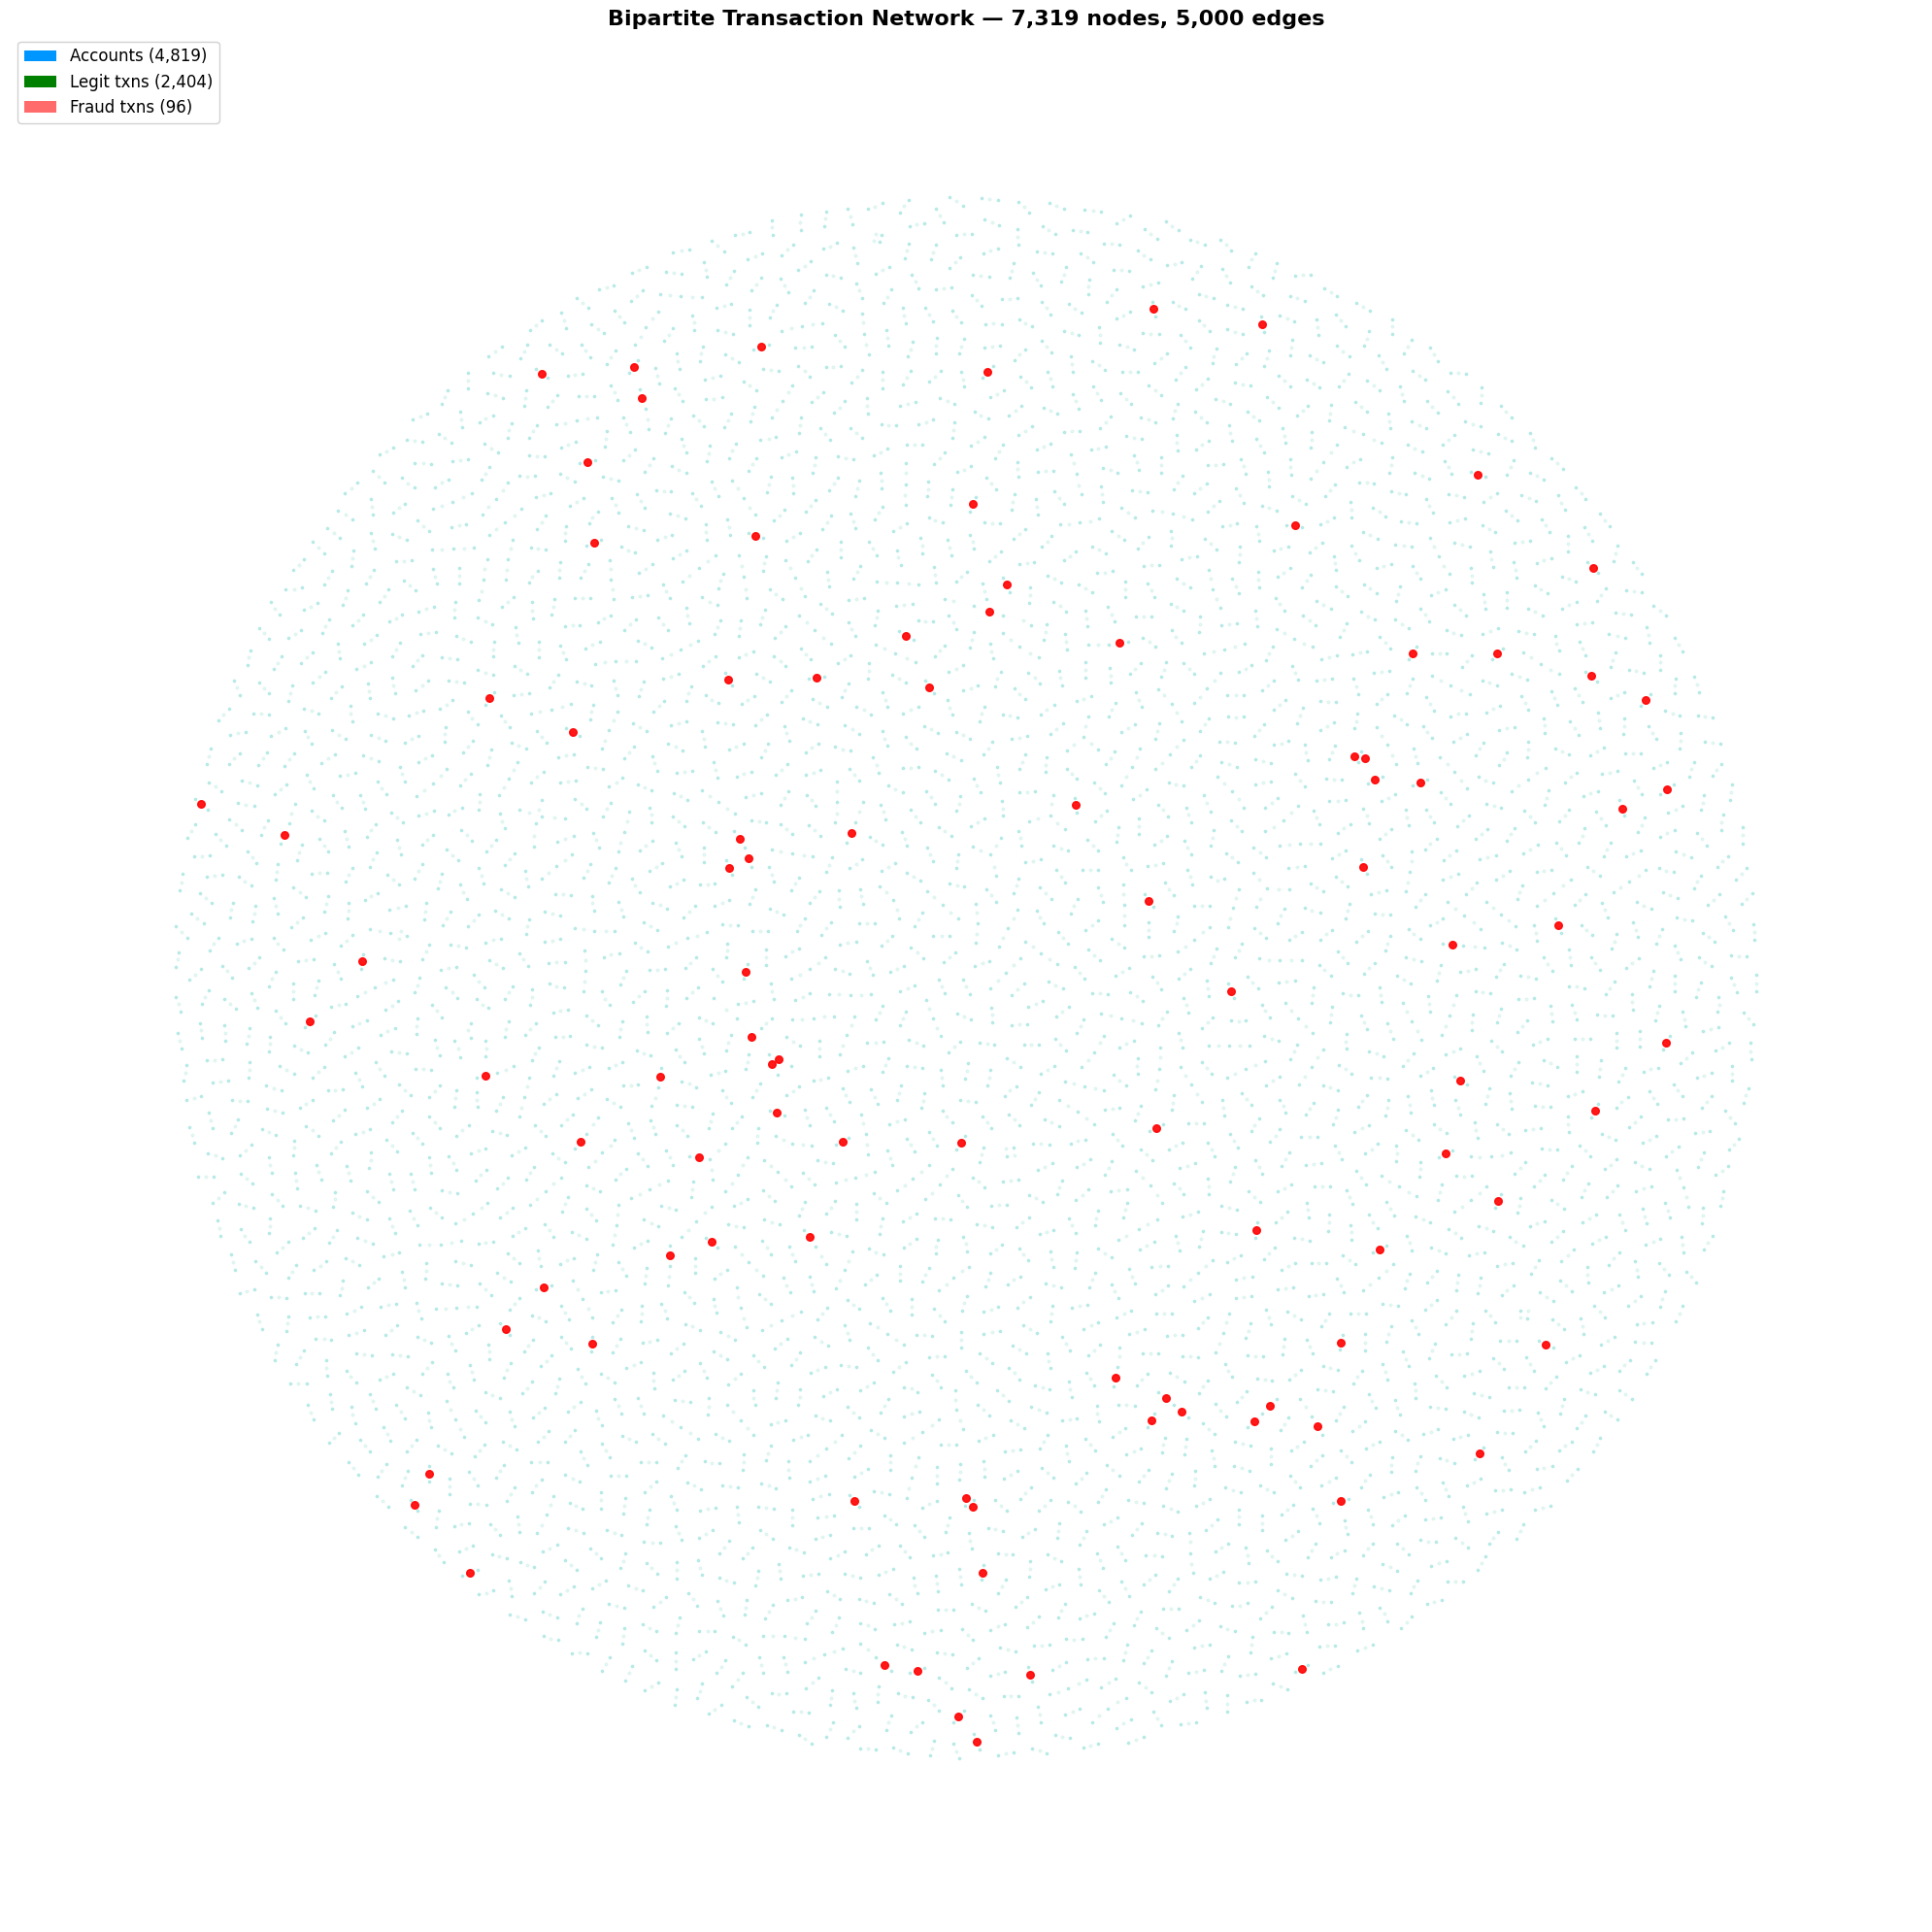

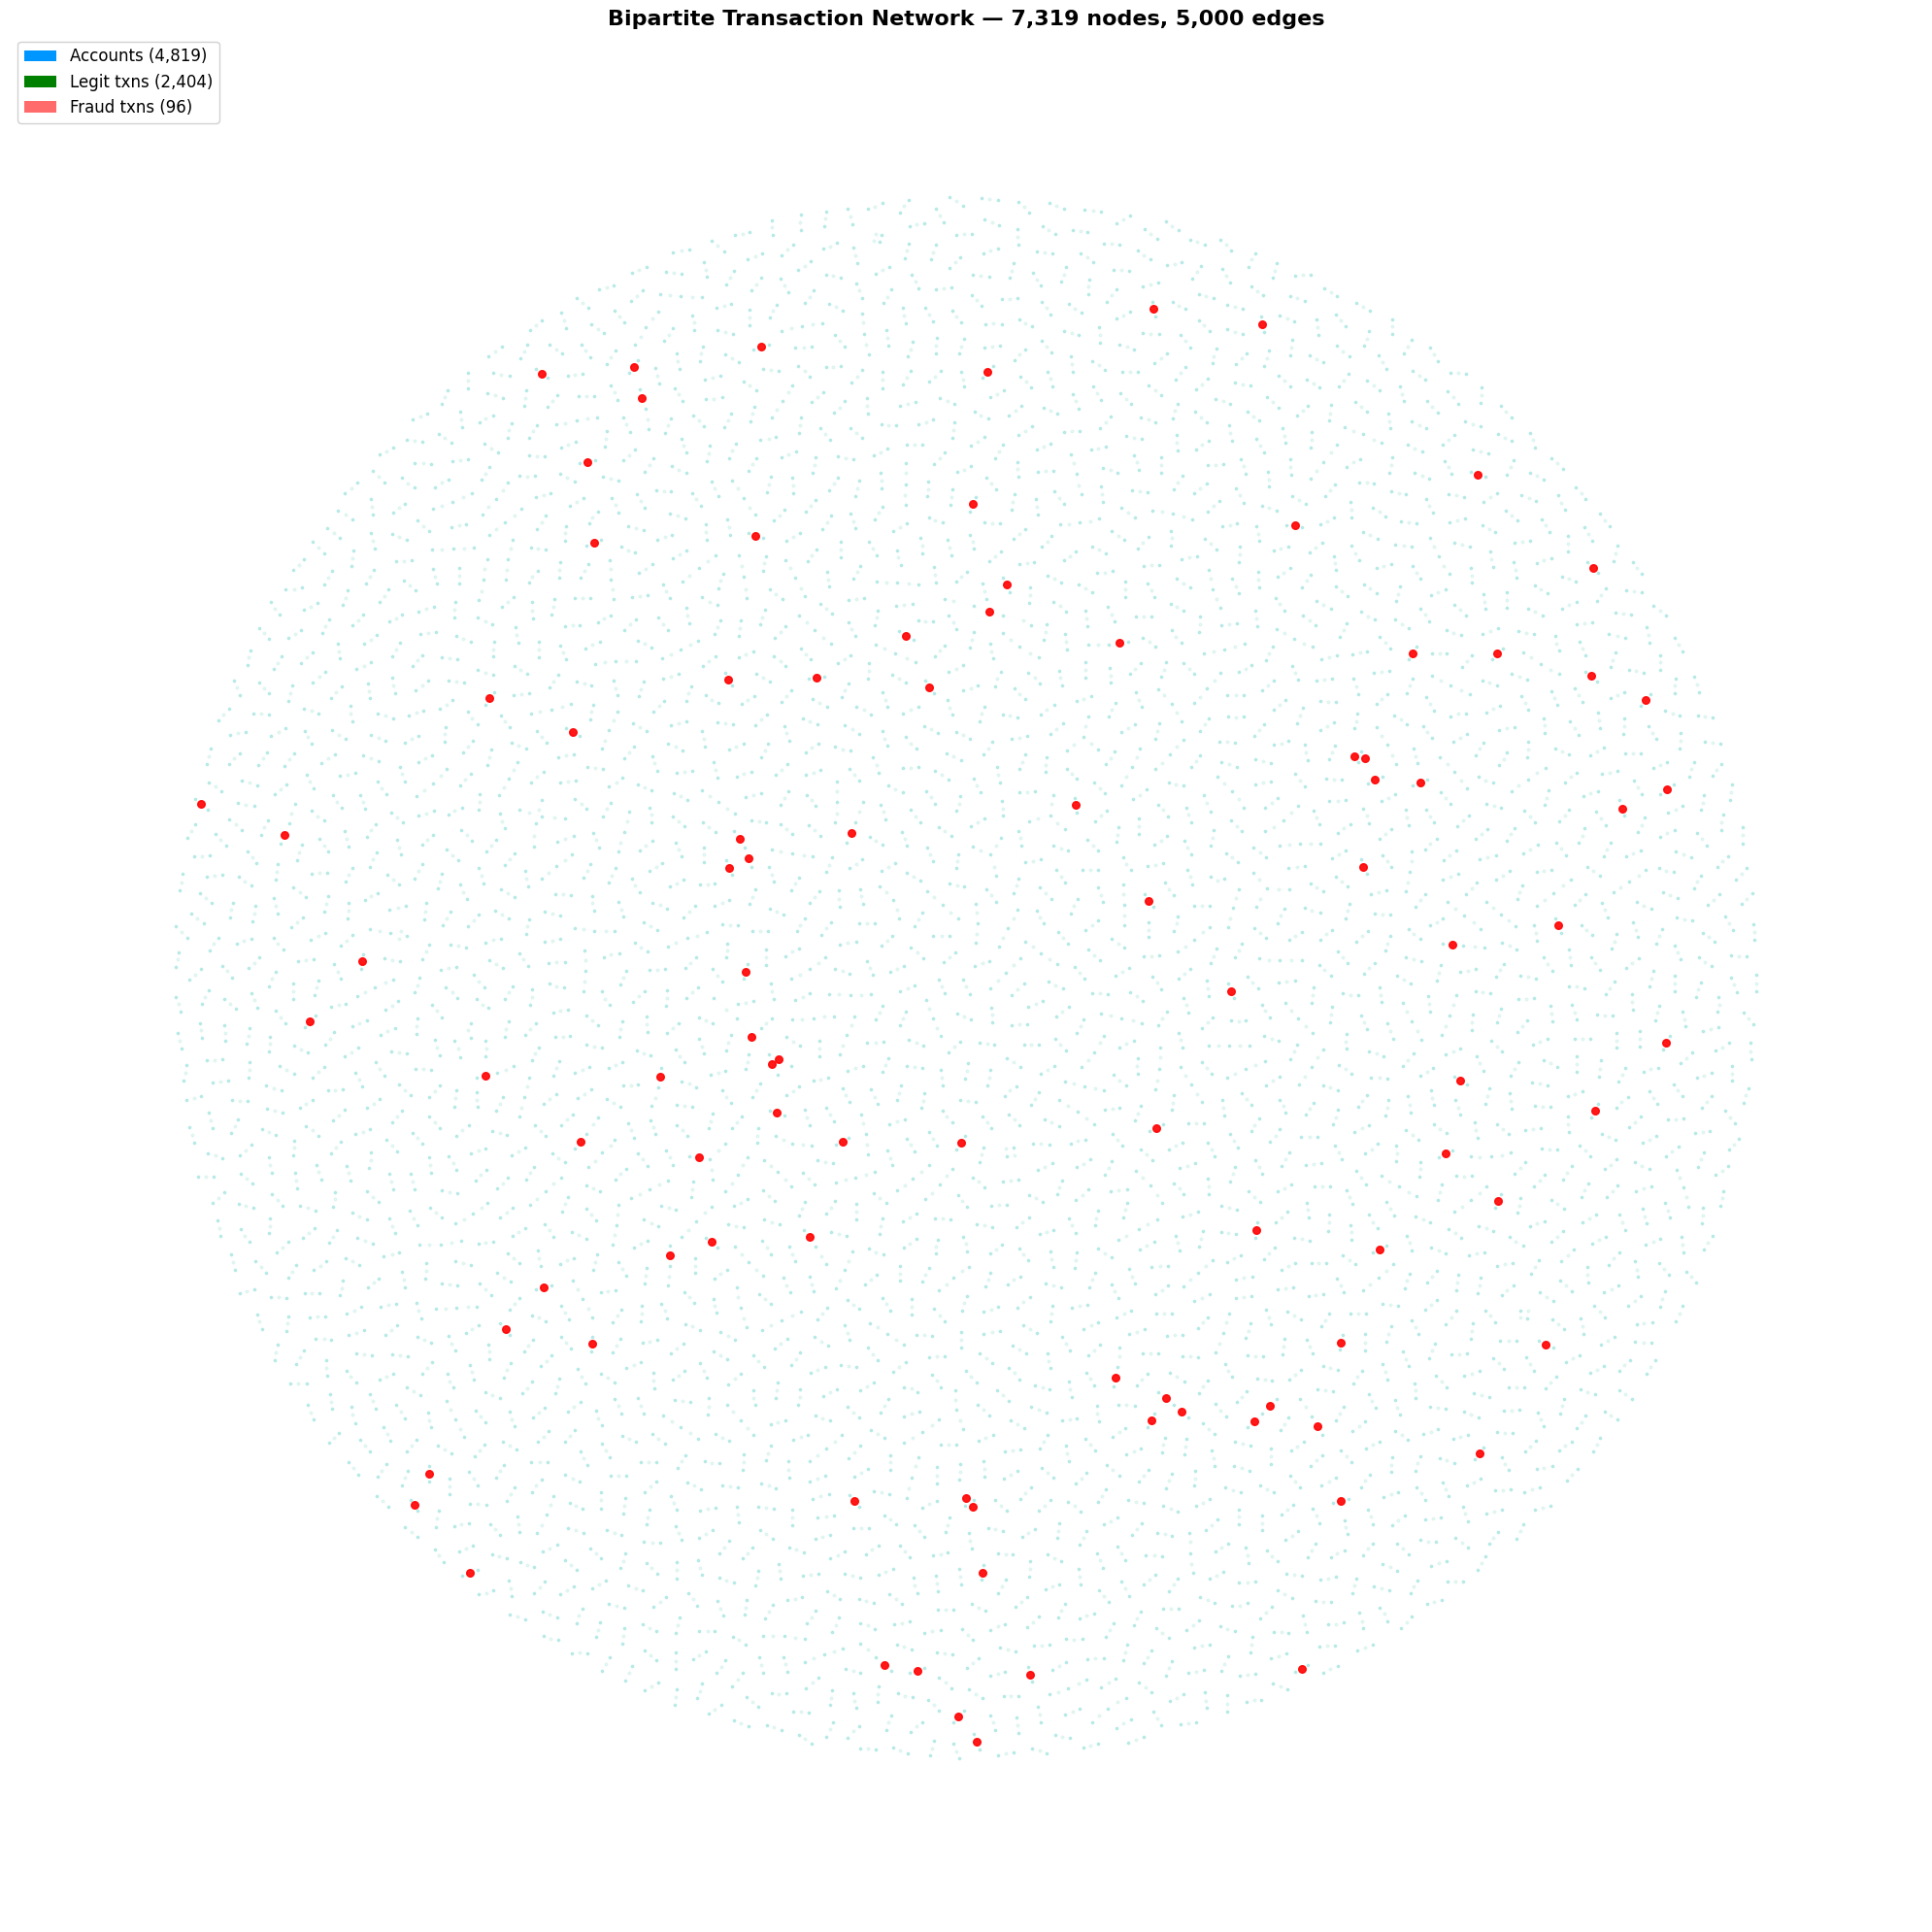

In [8]:
from scripts.visualize_graph import plot_full_network

# data and account_to_id from your earlier build_graph call
plot_full_network(data, max_nodes=5000)

---

In [2]:
df = pd.read_csv("../datasets/SAML-D.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9504852 entries, 0 to 9504851
Data columns (total 12 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   Time                    object 
 1   Date                    object 
 2   Sender_account          int64  
 3   Receiver_account        int64  
 4   Amount                  float64
 5   Payment_currency        object 
 6   Received_currency       object 
 7   Sender_bank_location    object 
 8   Receiver_bank_location  object 
 9   Payment_type            object 
 10  Is_laundering           int64  
 11  Laundering_type         object 
dtypes: float64(1), int64(3), object(8)
memory usage: 870.2+ MB


In [5]:
df["Laundering_type"].value_counts()

Laundering_type
Normal_Small_Fan_Out      3477717
Normal_Fan_Out            2302220
Normal_Fan_In             2104285
Normal_Group               528351
Normal_Cash_Withdrawal     305031
Normal_Cash_Deposits       223801
Normal_Periodical          210526
Normal_Plus_Mutual         155041
Normal_Mutual              125335
Normal_Foward               42031
Normal_single_large         20641
Structuring                  1870
Cash_Withdrawal              1334
Deposit-Send                  945
Smurfing                      932
Layered_Fan_In                656
Layered_Fan_Out               529
Stacked Bipartite             506
Behavioural_Change_1          394
Bipartite                     383
Cycle                         382
Fan_In                        364
Gather-Scatter                354
Behavioural_Change_2          345
Scatter-Gather                338
Single_large                  250
Fan_Out                       237
Over-Invoicing                 54
Name: count, dtype: int64

In [7]:
df.isnull().sum()

Time                      0
Date                      0
Sender_account            0
Receiver_account          0
Amount                    0
Payment_currency          0
Received_currency         0
Sender_bank_location      0
Receiver_bank_location    0
Payment_type              0
Is_laundering             0
Laundering_type           0
dtype: int64

In [8]:
df.head()

,Time,Date,Sender_account,Receiver_account,Amount,Payment_currency,Received_currency,Sender_bank_location,Receiver_bank_location,Payment_type,Is_laundering,Laundering_type
0,10:35:19,2022-10-07,8724731955,2769355426,1459.15,UK pounds,UK pounds,UK,UK,Cash Deposit,0,Normal_Cash_Deposits
1,10:35:20,2022-10-07,1491989064,8401255335,6019.64,UK pounds,Dirham,UK,UAE,Cross-border,0,Normal_Fan_Out
2,10:35:20,2022-10-07,287305149,4404767002,14328.44,UK pounds,UK pounds,UK,UK,Cheque,0,Normal_Small_Fan_Out
3,10:35:21,2022-10-07,5376652437,9600420220,11895.00,UK pounds,UK pounds,UK,UK,ACH,0,Normal_Fan_In
4,10:35:21,2022-10-07,9614186178,3803336972,115.25,UK pounds,UK pounds,UK,UK,Cash Deposit,0,Normal_Cash_Deposits
